# Demag re-run — data schema & quick parse

`./data/` 아래 `.npz` 결과 파일의 **키 / 의미 / shape / 원천 rate** 를 정리하고, 아주 기본적인 파싱 · 시계열 플롯 예시 까지만 보여줍니다.

추가 분석 (12 관절 전체, 베이스 상태, 감자 ratio 요약표, 4×3 그리드, PD vs MethodA 비교 …) 은 [`view_data_detailed.ipynb`](./view_data_detailed.ipynb) 참고.

## 저장 스키마 (v4: tau_des / I_des 추가)

모든 배열은 **N = `meta['num_steps']` 행** 으로 길이가 동일하고 **50 Hz (log dt = 20 ms = `meta['dt']`) 로 기록** 됩니다. 시간축은 전부 `t = np.arange(N) * meta['dt']` 하나만 있으면 됩니다.

원천 신호가 **실제로 업데이트되는 rate** 는 세 가지:
- **physics (0.1 ms)** — MuJoCo 적분기 substep.
- **pd loop (5 ms)** — PD + DC motor saturation + V_bus clamp 가 재계산되는 주기 (`pd_substeps=50 · physics_dt`).
- **policy (20 ms)** — 신경망 정책이 `q_des` 를 갱신하는 주기.

### MethodA 제어 파이프라인 (감자 실험은 모두 이 경로)

```
policy (20 ms) → q_des
       │
       ▼ pd loop (5 ms)
       tau_des = envelope(Kp·(q_des − q) − Kd·qd)   ← pre V_bus (DC torque-speed envelope 까지 반영)
       I_des   = tau_des / (Kt_nominal · gr)        ← 컨트롤러: nominal Kt
       V       = R·I_des + Ke_nominal·gr·ω          ← 컨트롤러: nominal Ke (back-EMF FF)
       V       = clamp(V, ±V_bus)                    ← ★ 전압 포화 ★
       ctrl    = (V − Ke_nominal·gr·ω) / R           ← data.ctrl (= I_cmd, post-clamp)
       tau_cmd = I_cmd · Kt_nominal
       │
       ▼ physics (0.1 ms)
       filterexact ODE: dI/dt = (R·ctrl − R·I) / L  (plant Ke = actuator_dynprm[·, 1] 도 ODE 에 반영)
       I_actual
       tau_actual = (Kt_nominal · gr · factor) · I_actual   ← 플랜트: fault Kt = gainprm[·, 0]
```

**컨트롤러 vs 플랜트 Kt / Ke 분리 (demag 주입 지점)**:

| 파라미터 | 컨트롤러 (항상 nominal) | 플랜트 (fault 반영) |
|---|---|---|
| Kt · gr | `NativeElectricActuator._Ktgr` (init 시 캐시, 런타임 수정 없음) | `actuator_gainprm[idx, 0] = Kt_nom·gr · factor` |
| Ke · gr | `NativeElectricActuator._Kegr` (init 시 캐시, 런타임 수정 없음) | `actuator_dynprm[idx, 1] = Ke_nom·gr · factor` |

`inject_demagnetization()` 은 **플랜트 쪽만** 스케일하고, 컨트롤러는 demag 존재 자체를 모릅니다. 따라서 I_des 와 back-EMF FF 는 모두 nominal Kt/Ke 로 계산됩니다.

### 저장 키 전부

per-joint 배열(`(N, 12)`) 의 **열 순서는 `meta['q_all_joint_names']`** 에 기록됩니다 (런타임에 MuJoCo 모델에서 추출).

| 키 | shape | 원천 rate | 의미 |
|---|---|---|---|
| `tau_des` | (N, 12) | pd loop (5 ms) | **PD 직출력** `envelope(Kp·(q_des−q) − Kd·qd)` [N·m]. DC motor torque-speed envelope 및 effort_limit 은 거쳤지만 **V_bus 포화 이전**. `NativeElectricActuator._tau_des_hold` 에서 읽음. PD baseline 은 `tau_actual` 미러 |
| `tau_cmd` | (N, 12) | pd loop (5 ms) | `I_cmd · Kt_nominal` [N·m], **V_bus 포화 이후**. 전압 비포화 시 `tau_des` 와 일치, 포화 시 `tau_cmd < tau_des` |
| `tau_actual` | (N, 12) | physics (0.1 ms) | 실제 관절 토크 `qfrc_actuator = Kt_plant · gr · I_actual` [N·m]. demag 반영 |
| `I_des` | (N, 12) | pd loop (5 ms) | `tau_des / Kt_nominal` [A], **pre-V_bus** 목표 전류 |
| `I_cmd` | (N, 12) | pd loop (5 ms) | `data.ctrl` [A], **post-V_bus** 전류 지령. PD baseline 은 `tau_cmd / Kt` 로 derive |
| `I_actual` | (N, 12) | physics (0.1 ms) | 실제 코일 전류 `act` [A] (filterexact ODE 적분값, τ_e ≈ L/R 로 `I_cmd` 추종). PD baseline: `I_cmd` 와 동일 |
| `q_all` | (N, 12) | physics (0.1 ms) | 12 관절 각도 `qpos` [rad] |
| `qd_all` | (N, 12) | physics (0.1 ms) | 12 관절 각속도 `qvel` [rad/s] |
| `q_des` | (N, 12) | policy (20 ms) | 정책 출력 관절 위치 목표 [rad] (`raw_action · scale + default_joint_pos`) |
| `foot_contact` | (N, 4) | physics (0.1 ms) | 발 접촉 플래그 (0/1). 열 순서는 `meta['foot_contact_names']` |
| `base_pos` | (N, 3) | physics (0.1 ms) | 베이스 `(x, y, z)` **world frame** [m] |
| `base_quat` | (N, 4) | physics (0.1 ms) | 베이스 쿼터니언 `[w, x, y, z]` (MuJoCo scalar-first) |
| `base_rpy` | (N, 3) | physics (0.1 ms) | `[roll, pitch, yaw]` **ZYX intrinsic** [rad] |
| `base_lin_vel` | (N, 3) | physics (0.1 ms) | **body frame** 선속도 [m/s] |
| `base_ang_vel` | (N, 3) | physics (0.1 ms) | **body frame** 각속도 [rad/s] |
| `cmd_vel` | (N, 3) | constant | 명령 `(vx, vy, wz)` — 실험 전체 구간에서 고정 (`meta['cmd']` 와 동일, 본 실험은 `vx=0.5 m/s`). 매 policy step 로깅하지만 값은 변하지 않음 |
| `meta` | JSON (0-d) | — | policy, demag_leg, demag_factor, dt, fs, joint_names, quat/rpy convention, 각 키 설명 note … |

### V_bus 포화 진단

가장 직관적인 체크: **`tau_des` 와 `tau_cmd` 의 차이**. 비포화 구간에서는 두 값이 정확히 일치하고, 포화 구간에서만 `tau_des > tau_cmd` (혹은 음수 영역에서 `tau_des < tau_cmd`). Demag 는 Kt 감소로 I 수요를 키워 전압 포화 가능성을 올리므로, 결함 케이스의 포화 빈도를 tau_des vs tau_cmd gap 으로 정량화할 수 있습니다.

### `meta` 주요 필드
- `num_steps`, `dt` (= 0.02 s), `fs` (= 50 Hz) — 시간축 복원용.
- `q_all_joint_names` — 12 관절 이름 (per-joint 배열 열 순서).
- `foot_contact_names` — 발 접촉 센서의 geom 이름 순서.
- `demag_leg` ∈ `{FL, FR, RL, RR, none}`, `demag_factor` ∈ `[0, 1]` — healthy 파일은 `demag_leg="none"`.
- `kt_nominal_joint`, `ke_nominal_joint` — 컨트롤러가 사용하는 nominal Kt·gr, Ke·gr.
- `cmd` — 실험에 쓴 고정 속도 명령 `(vx, vy, wz)`.
- `q_des_note`, `tau_cmd_note`, `tau_des_note`, `I_des_note`, `foot_contact_note` — 각 키의 추가 설명.

### 파일 트리
- `data/methoda/healthy.npz` — 감자 없음 (MethodA 전류 제어)
- `data/methoda/{FL,FR,RL,RR}_{0.8,0.6,0.4}.npz` — 12 감자 케이스
- `data/pd/nominal.npz` — PD 제어 베이스라인

## 파싱 예시

`.npz` 파일 하나를 열어서 안에 뭐가 들어있는지 확인하는 가장 단순한 방법입니다.

1. `np.load(...)` 로 파일을 연다 → 키로 접근 가능한 객체.
2. `tau_actual`, `q_all` 같은 배열은 바로 `["키 이름"]` 으로 꺼낸다.
3. `meta` 는 JSON 문자열로 저장돼 있으므로 `json.loads(...)` 로 dict 로 변환한다.

In [1]:
import json
import numpy as np

# 1) 파일 열기
file_path = "./data/methoda/FL_0.6.npz"
data = np.load(file_path, allow_pickle=True)

# 2) 들어있는 키 전부 확인
print("keys:", list(data.files))

# 3) 배열 꺼내기 — shape 로 크기 확인
tau_des    = data["tau_des"]      # (N, 12), pd loop 5 ms (pre-V_bus)
tau_cmd    = data["tau_cmd"]      # (N, 12), pd loop 5 ms (post-V_bus)
tau_actual = data["tau_actual"]   # (N, 12), physics 0.1 ms
I_des      = data["I_des"]        # (N, 12), pd loop 5 ms
q_des      = data["q_des"]        # (N, 12), policy 20 ms
print("tau_des shape    :", tau_des.shape)
print("tau_cmd shape    :", tau_cmd.shape)
print("tau_actual shape :", tau_actual.shape)
print("I_des shape      :", I_des.shape)
print("q_des shape      :", q_des.shape)

# 4) meta 는 JSON 문자열 → dict 로 변환
meta = json.loads(str(data["meta"]))
print("\n[meta] 주요 필드")
print("  num_steps    :", meta["num_steps"])
print("  dt (log)     :", meta["dt"], "s  (=", meta["fs"], "Hz)")
print("  cmd          :", meta["cmd"])
print("  demag_leg    :", meta["demag_leg"])
print("  demag_factor :", meta["demag_factor"])
print("  joint_names  :", meta["q_all_joint_names"])

keys: ['tau_cmd', 'tau_des', 'tau_actual', 'I_cmd', 'I_des', 'I_actual', 'q_all', 'qd_all', 'q_des', 'foot_contact', 'base_pos', 'base_quat', 'base_rpy', 'base_lin_vel', 'base_ang_vel', 'cmd_vel', 'meta']
tau_des shape    : (1000, 12)
tau_cmd shape    : (1000, 12)
tau_actual shape : (1000, 12)
I_des shape      : (1000, 12)
q_des shape      : (1000, 12)

[meta] 주요 필드
  num_steps    : 1000
  dt (log)     : 0.02 s  (= 50.0 Hz)
  cmd          : {'vx': 0.5, 'vy': 0.0, 'wz': 0.0}
  demag_leg    : FL
  demag_factor : 0.6
  joint_names  : ['FL_hip_joint', 'FR_hip_joint', 'RL_hip_joint', 'RR_hip_joint', 'FL_thigh_joint', 'FR_thigh_joint', 'RL_thigh_joint', 'RR_thigh_joint', 'FL_calf_joint', 'FR_calf_joint', 'RL_calf_joint', 'RR_calf_joint']


### 특정 관절 하나만 꺼내기

per-joint 배열은 **12 개 관절 전부** 를 담고 있습니다 (shape `(N, 12)`). 원하는 관절의 **열 번호** 를 `q_all_joint_names` 리스트에서 찾으면 됩니다.

In [3]:
# joint 이름 → 열 번호
joint_names = meta["q_all_joint_names"]
col = joint_names.index("FL_calf_joint")
print(f"FL_calf_joint 은 {col} 번째 열")

# 그 열만 꺼내면 (N,) 1-D 시계열
tau_FL_calf_des    = tau_des[:, col]
tau_FL_calf_cmd    = tau_cmd[:, col]
tau_FL_calf_actual = tau_actual[:, col]
print("FL_calf tau_actual 첫 5 step:", tau_FL_calf_actual[:5])

FL_calf_joint 은 8 번째 열
FL_calf tau_actual 첫 5 step: [-0.508415   5.4441943  9.899476  11.017323  11.342753 ]


## 시계열 플롯 예시 — FL_calf 의 τ_des vs τ_cmd vs τ_actual

시간축은 `meta['dt']` 로부터 만들 수 있습니다: `t[i] = i * dt`.

세 양의 차이를 한 번에 봅니다:
- `τ_des` (점선, 연한 빨강): PD 가 원하는 토크 (**V_bus 포화 전**).
- `τ_cmd` (점선, 빨강): `I_cmd · Kt_nominal`, **V_bus 포화 후** 전류 지령의 토크 등가치.
- `τ_actual` (실선, 파랑): 관절에 실제 걸린 토크 (demag plant Kt 반영).

포화가 전혀 없다면 `τ_des == τ_cmd` 로 겹칩니다. FL demag ×0.6 에서는 controller 가 모르는 채로 동일한 전류를 명령하므로 `τ_cmd` 와 `τ_actual` 사이에 0.6 배 gap 이, `τ_des == τ_cmd` 이면 전압 포화가 아직 발생하지 않은 구간입니다.

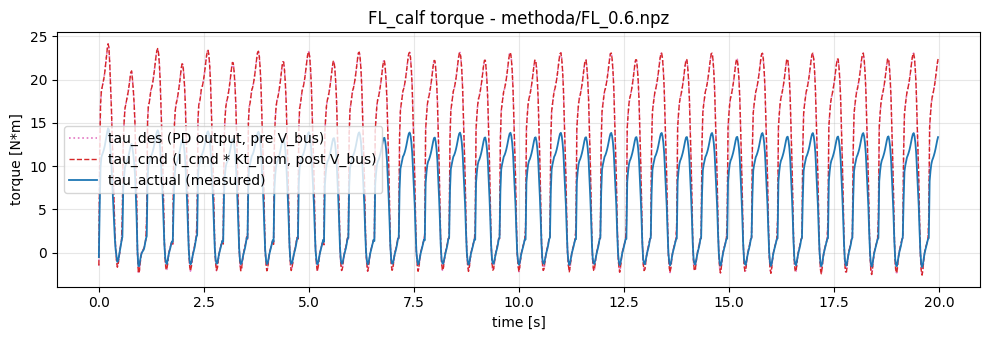

FL_calf V_bus saturation step fraction: 0.0% (max gap: 0.000 N*m)


In [7]:
import matplotlib.pyplot as plt

# 시간축 만들기: 0, dt, 2·dt, ... (num_steps-1)·dt
t = np.arange(meta["num_steps"]) * meta["dt"]

plt.figure(figsize=(10, 3.5))
plt.plot(t, tau_FL_calf_des,    label="tau_des (PD output, pre V_bus)",       color="tab:pink", ls=":",  lw=1.2)
plt.plot(t, tau_FL_calf_cmd,    label="tau_cmd (I_cmd * Kt_nom, post V_bus)", color="tab:red",  ls="--", lw=1.0)
plt.plot(t, tau_FL_calf_actual, label="tau_actual (measured)",                color="tab:blue", ls="-",  lw=1.3)
plt.xlabel("time [s]")
plt.ylabel("torque [N*m]")
plt.title("FL_calf torque - methoda/FL_0.6.npz")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# V_bus 포화 빈도 진단: |tau_des - tau_cmd| > 1e-3 인 step 비율
gap = np.abs(tau_FL_calf_des - tau_FL_calf_cmd)
sat_frac = float(np.mean(gap > 1e-3))
print(f"FL_calf V_bus saturation step fraction: {sat_frac:.1%} "
      f"(max gap: {gap.max():.3f} N*m)")